## 16. Missing Value Validation

Before exporting the feature-engineered dataset, missing values are checked across all engineered features.

This step ensures that the dataset is suitable for downstream demand forecasting and identifies any features that may require additional treatment.

In [5]:
# Check missing values in the feature-engineered dataset

missing_features = df.isna().sum()

missing_features = (
    missing_features[missing_features > 0]
    .sort_values(ascending=False)
)

print("Missing values in feature-engineered dataset:")
print("-" * 50)

if missing_features.empty:
    print("No missing values found.")
else:
    print(missing_features)

NameError: name 'df' is not defined

In [7]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the analysis-ready dataset
df = pd.read_csv("../data/processed/analysis_ready.csv")

print("Dataset loaded successfully.")
print("Shape:", df.shape)

Dataset loaded successfully.
Shape: (20906, 26)


In [8]:
# Display basic information about the dataset

print("Dataset shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

Dataset shape: (20906, 26)

Columns:
['date', 'sku_id', 'units_sold', 'revenue', 'price', 'promo_flag', 'calculated_revenue', 'revenue_difference', 'revenue_consistency_flag', 'category', 'subcategory', 'launch_date', 'unit_cost', 'list_price', 'sku_quality_flag', 'week', 'month', 'season', 'is_holiday', 'promo_event', 'promo_flag_calendar', 'on_hand_units', 'on_order_units', 'lead_time_days', 'reorder_point', 'inventory_quality_flag']

First 5 rows:


,date,sku_id,units_sold,revenue,price,promo_flag,calculated_revenue,revenue_difference,revenue_consistency_flag,category,...,month,season,is_holiday,promo_event,promo_flag_calendar,on_hand_units,on_order_units,lead_time_days,reorder_point,inventory_quality_flag
0,2025-01-01,SKU001,52.0,245974.56,4730.28,0,245974.56,0.000000e+00,OK,Furniture,...,1,Winter,0,NaN,0,284.0,125,6.0,255,OK
1,2025-01-02,SKU001,69.0,326389.32,4730.28,0,326389.32,0.000000e+00,OK,Furniture,...,1,Winter,0,NaN,0,215.0,128,6.0,255,OK
2,2025-01-03,SKU001,49.0,231783.72,4664.22,0,228546.78,3.236940e+03,REVENUE_MISMATCH,Furniture,...,1,Winter,0,NaN,0,166.0,186,6.0,255,OK
3,2025-01-04,SKU001,74.0,350040.72,7387.17,0,546650.58,-1.966099e+05,REVENUE_MISMATCH,Furniture,...,1,Winter,0,NaN,0,92.0,62,6.0,255,OK
4,2025-01-05,SKU001,43.0,203402.04,4730.28,0,203402.04,2.910383e-11,OK,Furniture,...,1,Winter,0,NaN,0,49.0,112,6.0,255,OK


In [9]:
# Check data types and missing values

print("Data Types:")
display(df.dtypes)

print("\nMissing Values:")
missing_values = df.isnull().sum().sort_values(ascending=False)
display(missing_values)

Data Types:


date                            str
sku_id                          str
units_sold                  float64
revenue                     float64
price                       float64
promo_flag                    int64
calculated_revenue          float64
revenue_difference          float64
revenue_consistency_flag        str
category                        str
subcategory                     str
launch_date                     str
unit_cost                   float64
list_price                  float64
sku_quality_flag                str
week                          int64
month                         int64
season                          str
is_holiday                    int64
promo_event                     str
promo_flag_calendar           int64
on_hand_units               float64
on_order_units                int64
lead_time_days              float64
reorder_point                 int64
inventory_quality_flag          str
dtype: object


Missing Values:


promo_event                 17634
unit_cost                     546
on_hand_units                  40
calculated_revenue             25
revenue_difference             25
units_sold                     15
price                          10
promo_flag                      0
sku_id                          0
date                            0
category                        0
revenue_consistency_flag        0
revenue                         0
subcategory                     0
sku_quality_flag                0
week                            0
launch_date                     0
list_price                      0
season                          0
month                           0
is_holiday                      0
promo_flag_calendar             0
on_order_units                  0
lead_time_days                  0
reorder_point                   0
inventory_quality_flag          0
dtype: int64

In [10]:
# Convert date column to datetime format

df["date"] = pd.to_datetime(df["date"], errors="coerce")

# Check the date range

print("Minimum Date:", df["date"].min())
print("Maximum Date:", df["date"].max())

print("\nInvalid Dates:", df["date"].isna().sum())

Minimum Date: 2025-01-01 00:00:00
Maximum Date: 2026-06-30 00:00:00

Invalid Dates: 0


In [11]:
# Create basic calendar features from the date column

df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["week"] = df["date"].dt.isocalendar().week.astype(int)
df["day_of_week"] = df["date"].dt.dayofweek
df["day_of_month"] = df["date"].dt.day

# Monday = 0, Sunday = 6
df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)

df[[
    "date",
    "year",
    "month",
    "week",
    "day_of_week",
    "day_of_month",
    "is_weekend"
]].head()

,date,year,month,week,day_of_week,day_of_month,is_weekend
0,2025-01-01,2025,1,1,2,1,0
1,2025-01-02,2025,1,1,3,2,0
2,2025-01-03,2025,1,1,4,3,0
3,2025-01-04,2025,1,1,5,4,1
4,2025-01-05,2025,1,1,6,5,1


In [12]:
# Sort data before creating lag features

df = df.sort_values(["sku_id", "date"]).reset_index(drop=True)

# Create historical demand features

df["lag_1"] = df.groupby("sku_id")["units_sold"].shift(1)
df["lag_7"] = df.groupby("sku_id")["units_sold"].shift(7)
df["lag_14"] = df.groupby("sku_id")["units_sold"].shift(14)
df["lag_28"] = df.groupby("sku_id")["units_sold"].shift(28)

df[[
    "date",
    "sku_id",
    "units_sold",
    "lag_1",
    "lag_7",
    "lag_14",
    "lag_28"
]].head(35)

,date,sku_id,units_sold,lag_1,lag_7,lag_14,lag_28
0,2025-01-01,SKU001,52.0,NaN,NaN,NaN,NaN
1,2025-01-02,SKU001,69.0,52.0,NaN,NaN,NaN
2,2025-01-03,SKU001,49.0,69.0,NaN,NaN,NaN
3,2025-01-04,SKU001,74.0,49.0,NaN,NaN,NaN
4,2025-01-05,SKU001,43.0,74.0,NaN,NaN,NaN
5,2025-01-06,SKU001,56.0,43.0,NaN,NaN,NaN
6,2025-01-07,SKU001,46.0,56.0,NaN,NaN,NaN
7,2025-01-08,SKU001,51.0,46.0,52.0,NaN,NaN
8,2025-01-09,SKU001,65.0,51.0,69.0,NaN,NaN
9,2025-01-10,SKU001,70.0,65.0,49.0,NaN,NaN


In [13]:
# Create rolling demand statistics using previous observations

df["rolling_mean_7"] = (
    df.groupby("sku_id")["units_sold"]
      .transform(lambda x: x.shift(1).rolling(7).mean())
)

df["rolling_mean_14"] = (
    df.groupby("sku_id")["units_sold"]
      .transform(lambda x: x.shift(1).rolling(14).mean())
)

df["rolling_mean_28"] = (
    df.groupby("sku_id")["units_sold"]
      .transform(lambda x: x.shift(1).rolling(28).mean())
)

df[[
    "date",
    "sku_id",
    "units_sold",
    "rolling_mean_7",
    "rolling_mean_14",
    "rolling_mean_28"
]].head(35)

,date,sku_id,units_sold,rolling_mean_7,rolling_mean_14,rolling_mean_28
0,2025-01-01,SKU001,52.0,NaN,NaN,NaN
1,2025-01-02,SKU001,69.0,NaN,NaN,NaN
2,2025-01-03,SKU001,49.0,NaN,NaN,NaN
3,2025-01-04,SKU001,74.0,NaN,NaN,NaN
4,2025-01-05,SKU001,43.0,NaN,NaN,NaN
5,2025-01-06,SKU001,56.0,NaN,NaN,NaN
6,2025-01-07,SKU001,46.0,NaN,NaN,NaN
7,2025-01-08,SKU001,51.0,55.571429,NaN,NaN
8,2025-01-09,SKU001,65.0,55.428571,NaN,NaN
9,2025-01-10,SKU001,70.0,54.857143,NaN,NaN


In [14]:
# Calculate rolling demand variability using previous observations

df["rolling_std_7"] = (
    df.groupby("sku_id")["units_sold"]
      .transform(lambda x: x.shift(1).rolling(7).std())
)

df["rolling_std_14"] = (
    df.groupby("sku_id")["units_sold"]
      .transform(lambda x: x.shift(1).rolling(14).std())
)

df["rolling_std_28"] = (
    df.groupby("sku_id")["units_sold"]
      .transform(lambda x: x.shift(1).rolling(28).std())
)

df[[
    "date",
    "sku_id",
    "units_sold",
    "rolling_std_7",
    "rolling_std_14",
    "rolling_std_28"
]].head(35)

,date,sku_id,units_sold,rolling_std_7,rolling_std_14,rolling_std_28
0,2025-01-01,SKU001,52.0,NaN,NaN,NaN
1,2025-01-02,SKU001,69.0,NaN,NaN,NaN
2,2025-01-03,SKU001,49.0,NaN,NaN,NaN
3,2025-01-04,SKU001,74.0,NaN,NaN,NaN
4,2025-01-05,SKU001,43.0,NaN,NaN,NaN
5,2025-01-06,SKU001,56.0,NaN,NaN,NaN
6,2025-01-07,SKU001,46.0,NaN,NaN,NaN
7,2025-01-08,SKU001,51.0,11.731115,NaN,NaN
8,2025-01-09,SKU001,65.0,11.787806,NaN,NaN
9,2025-01-10,SKU001,70.0,11.096975,NaN,NaN


In [15]:
# Calculate demand trend indicators

df["demand_trend_7_28"] = (
    df["rolling_mean_7"] - df["rolling_mean_28"]
)

df["demand_ratio_7_28"] = (
    df["rolling_mean_7"] /
    df["rolling_mean_28"].replace(0, np.nan)
)

df[[
    "date",
    "sku_id",
    "rolling_mean_7",
    "rolling_mean_28",
    "demand_trend_7_28",
    "demand_ratio_7_28"
]].head(35)

,date,sku_id,rolling_mean_7,rolling_mean_28,demand_trend_7_28,demand_ratio_7_28
0,2025-01-01,SKU001,NaN,NaN,NaN,NaN
1,2025-01-02,SKU001,NaN,NaN,NaN,NaN
2,2025-01-03,SKU001,NaN,NaN,NaN,NaN
3,2025-01-04,SKU001,NaN,NaN,NaN,NaN
4,2025-01-05,SKU001,NaN,NaN,NaN,NaN
5,2025-01-06,SKU001,NaN,NaN,NaN,NaN
6,2025-01-07,SKU001,NaN,NaN,NaN,NaN
7,2025-01-08,SKU001,55.571429,NaN,NaN,NaN
8,2025-01-09,SKU001,55.428571,NaN,NaN,NaN
9,2025-01-10,SKU001,54.857143,NaN,NaN,NaN


In [16]:
# Create promotion-related features

df["promo_flag"] = df["promo_flag"].fillna(0).astype(int)

df["promo_lag_1"] = (
    df.groupby("sku_id")["promo_flag"]
      .shift(1)
      .fillna(0)
      .astype(int)
)

df["promo_rolling_7"] = (
    df.groupby("sku_id")["promo_flag"]
      .transform(lambda x: x.shift(1).rolling(7).sum())
      .fillna(0)
)

df[[
    "date",
    "sku_id",
    "promo_flag",
    "promo_lag_1",
    "promo_rolling_7"
]].head(20)

,date,sku_id,promo_flag,promo_lag_1,promo_rolling_7
0,2025-01-01,SKU001,0,0,0.0
1,2025-01-02,SKU001,0,0,0.0
2,2025-01-03,SKU001,0,0,0.0
3,2025-01-04,SKU001,0,0,0.0
4,2025-01-05,SKU001,0,0,0.0
5,2025-01-06,SKU001,0,0,0.0
6,2025-01-07,SKU001,0,0,0.0
7,2025-01-08,SKU001,0,0,0.0
8,2025-01-09,SKU001,0,0,0.0
9,2025-01-10,SKU001,1,0,0.0


In [17]:
# Create price-related features

df["price_change"] = (
    df.groupby("sku_id")["price"]
      .pct_change()
      .replace([np.inf, -np.inf], np.nan)
      .fillna(0)
)

df["price_change_abs"] = (
    df.groupby("sku_id")["price"]
      .diff()
      .fillna(0)
)

df[[
    "date",
    "sku_id",
    "price",
    "price_change",
    "price_change_abs"
]].head(20)

,date,sku_id,price,price_change,price_change_abs
0,2025-01-01,SKU001,4730.28,0.000000,0.00
1,2025-01-02,SKU001,4730.28,0.000000,0.00
2,2025-01-03,SKU001,4664.22,-0.013965,-66.06
3,2025-01-04,SKU001,7387.17,0.583795,2722.95
4,2025-01-05,SKU001,4730.28,-0.359663,-2656.89
5,2025-01-06,SKU001,1404.39,-0.703106,-3325.89
6,2025-01-07,SKU001,4730.28,2.368210,3325.89
7,2025-01-08,SKU001,6462.39,0.366175,1732.11
8,2025-01-09,SKU001,6462.39,0.000000,0.00
9,2025-01-10,SKU001,3737.54,-0.421647,-2724.85


In [18]:
# Create inventory-related features

df["stock_gap"] = (
    df["on_hand_units"] - df["reorder_point"]
)

df["incoming_stock_ratio"] = (
    df["on_order_units"] / (df["on_hand_units"] + 1)
)

df["stockout_flag"] = (
    df["on_hand_units"] <= 0
).astype(int)

df[[
    "date",
    "sku_id",
    "on_hand_units",
    "on_order_units",
    "reorder_point",
    "stock_gap",
    "incoming_stock_ratio",
    "stockout_flag"
]].head(20)

,date,sku_id,on_hand_units,on_order_units,reorder_point,stock_gap,incoming_stock_ratio,stockout_flag
0,2025-01-01,SKU001,284.0,125,255,29.0,0.438596,0
1,2025-01-02,SKU001,215.0,128,255,-40.0,0.592593,0
2,2025-01-03,SKU001,166.0,186,255,-89.0,1.113772,0
3,2025-01-04,SKU001,92.0,62,255,-163.0,0.666667,0
4,2025-01-05,SKU001,49.0,112,255,-206.0,2.240000,0
5,2025-01-06,SKU001,50.0,0,255,-205.0,0.000000,0
6,2025-01-07,SKU001,4.0,64,255,-251.0,12.800000,0
7,2025-01-08,SKU001,0.0,127,255,-255.0,127.000000,1
8,2025-01-09,SKU001,0.0,43,255,-255.0,43.000000,1
9,2025-01-10,SKU001,0.0,49,255,-255.0,49.000000,1


In [19]:
# Create replenishment-related features

df["reorder_risk_flag"] = (
    df["on_hand_units"] < df["reorder_point"]
).astype(int)

df["lead_time_risk_flag"] = (
    (df["on_hand_units"] < df["reorder_point"]) &
    (df["lead_time_days"] > df["lead_time_days"].median())
).astype(int)

df[[
    "date",
    "sku_id",
    "on_hand_units",
    "reorder_point",
    "lead_time_days",
    "reorder_risk_flag",
    "lead_time_risk_flag"
]].head(20)

,date,sku_id,on_hand_units,reorder_point,lead_time_days,reorder_risk_flag,lead_time_risk_flag
0,2025-01-01,SKU001,284.0,255,6.0,0,0
1,2025-01-02,SKU001,215.0,255,6.0,1,0
2,2025-01-03,SKU001,166.0,255,6.0,1,0
3,2025-01-04,SKU001,92.0,255,6.0,1,0
4,2025-01-05,SKU001,49.0,255,6.0,1,0
5,2025-01-06,SKU001,50.0,255,6.0,1,0
6,2025-01-07,SKU001,4.0,255,6.0,1,0
7,2025-01-08,SKU001,0.0,255,6.0,1,0
8,2025-01-09,SKU001,0.0,255,6.0,1,0
9,2025-01-10,SKU001,0.0,255,6.0,1,0


In [20]:
# Create stockout-related features

df["stockout_flag"] = (
    df["on_hand_units"] <= 0
).astype(int)

df["stockout_risk_flag"] = (
    (df["on_hand_units"] <= 0) &
    (df["on_order_units"] <= 0)
).astype(int)

df[[
    "date",
    "sku_id",
    "on_hand_units",
    "on_order_units",
    "stockout_flag",
    "stockout_risk_flag"
]].head(20)

,date,sku_id,on_hand_units,on_order_units,stockout_flag,stockout_risk_flag
0,2025-01-01,SKU001,284.0,125,0,0
1,2025-01-02,SKU001,215.0,128,0,0
2,2025-01-03,SKU001,166.0,186,0,0
3,2025-01-04,SKU001,92.0,62,0,0
4,2025-01-05,SKU001,49.0,112,0,0
5,2025-01-06,SKU001,50.0,0,0,0
6,2025-01-07,SKU001,4.0,64,0,0
7,2025-01-08,SKU001,0.0,127,1,0
8,2025-01-09,SKU001,0.0,43,1,0
9,2025-01-10,SKU001,0.0,49,1,0


In [21]:
# Calculate inventory coverage based on recent demand

df["rolling_7_day_demand"] = (
    df.groupby("sku_id")["units_sold"]
      .transform(lambda x: x.rolling(7, min_periods=1).mean())
)

df["inventory_coverage_days"] = (
    df["on_hand_units"] /
    df["rolling_7_day_demand"].replace(0, np.nan)
)

df[[
    "date",
    "sku_id",
    "on_hand_units",
    "rolling_7_day_demand",
    "inventory_coverage_days"
]].head(20)

,date,sku_id,on_hand_units,rolling_7_day_demand,inventory_coverage_days
0,2025-01-01,SKU001,284.0,52.000000,5.461538
1,2025-01-02,SKU001,215.0,60.500000,3.553719
2,2025-01-03,SKU001,166.0,56.666667,2.929412
3,2025-01-04,SKU001,92.0,61.000000,1.508197
4,2025-01-05,SKU001,49.0,57.400000,0.853659
5,2025-01-06,SKU001,50.0,57.166667,0.874636
6,2025-01-07,SKU001,4.0,55.571429,0.071979
7,2025-01-08,SKU001,0.0,55.428571,0.000000
8,2025-01-09,SKU001,0.0,54.857143,0.000000
9,2025-01-10,SKU001,0.0,57.857143,0.000000


In [22]:
# Review the engineered dataset

print("Dataset shape:", df.shape)

print("\nEngineered columns:")
print(df.columns.tolist())

print("\nFirst 10 rows of engineered dataset:")
display(df.head(10))

Dataset shape: (20906, 54)

Engineered columns:
['date', 'sku_id', 'units_sold', 'revenue', 'price', 'promo_flag', 'calculated_revenue', 'revenue_difference', 'revenue_consistency_flag', 'category', 'subcategory', 'launch_date', 'unit_cost', 'list_price', 'sku_quality_flag', 'week', 'month', 'season', 'is_holiday', 'promo_event', 'promo_flag_calendar', 'on_hand_units', 'on_order_units', 'lead_time_days', 'reorder_point', 'inventory_quality_flag', 'year', 'day_of_week', 'day_of_month', 'is_weekend', 'lag_1', 'lag_7', 'lag_14', 'lag_28', 'rolling_mean_7', 'rolling_mean_14', 'rolling_mean_28', 'rolling_std_7', 'rolling_std_14', 'rolling_std_28', 'demand_trend_7_28', 'demand_ratio_7_28', 'promo_lag_1', 'promo_rolling_7', 'price_change', 'price_change_abs', 'stock_gap', 'incoming_stock_ratio', 'stockout_flag', 'reorder_risk_flag', 'lead_time_risk_flag', 'stockout_risk_flag', 'rolling_7_day_demand', 'inventory_coverage_days']

First 10 rows of engineered dataset:


,date,sku_id,units_sold,revenue,price,promo_flag,calculated_revenue,revenue_difference,revenue_consistency_flag,category,...,price_change,price_change_abs,stock_gap,incoming_stock_ratio,stockout_flag,reorder_risk_flag,lead_time_risk_flag,stockout_risk_flag,rolling_7_day_demand,inventory_coverage_days
0,2025-01-01,SKU001,52.0,245974.56,4730.28,0,245974.56,0.000000e+00,OK,Furniture,...,0.000000,0.00,29.0,0.438596,0,0,0,0,52.000000,5.461538
1,2025-01-02,SKU001,69.0,326389.32,4730.28,0,326389.32,0.000000e+00,OK,Furniture,...,0.000000,0.00,-40.0,0.592593,0,1,0,0,60.500000,3.553719
2,2025-01-03,SKU001,49.0,231783.72,4664.22,0,228546.78,3.236940e+03,REVENUE_MISMATCH,Furniture,...,-0.013965,-66.06,-89.0,1.113772,0,1,0,0,56.666667,2.929412
3,2025-01-04,SKU001,74.0,350040.72,7387.17,0,546650.58,-1.966099e+05,REVENUE_MISMATCH,Furniture,...,0.583795,2722.95,-163.0,0.666667,0,1,0,0,61.000000,1.508197
4,2025-01-05,SKU001,43.0,203402.04,4730.28,0,203402.04,2.910383e-11,OK,Furniture,...,-0.359663,-2656.89,-206.0,2.240000,0,1,0,0,57.400000,0.853659
5,2025-01-06,SKU001,56.0,264895.68,1404.39,0,78645.84,1.862498e+05,REVENUE_MISMATCH,Furniture,...,-0.703106,-3325.89,-205.0,0.000000,0,1,0,0,57.166667,0.874636
6,2025-01-07,SKU001,46.0,217592.88,4730.28,0,217592.88,2.910383e-11,OK,Furniture,...,2.368210,3325.89,-251.0,12.800000,0,1,0,0,55.571429,0.071979
7,2025-01-08,SKU001,51.0,241244.28,6462.39,0,329581.89,-8.833761e+04,REVENUE_MISMATCH,Furniture,...,0.366175,1732.11,-255.0,127.000000,1,1,0,0,55.428571,0.000000
8,2025-01-09,SKU001,65.0,307468.20,6462.39,0,420055.35,-1.125872e+05,REVENUE_MISMATCH,Furniture,...,0.000000,0.00,-255.0,43.000000,1,1,0,0,54.857143,0.000000
9,2025-01-10,SKU001,70.0,304630.03,3737.54,1,261627.80,4.300223e+04,REVENUE_MISMATCH,Furniture,...,-0.421647,-2724.85,-255.0,49.000000,1,1,0,0,57.857143,0.000000


# start

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully.")

Libraries imported successfully.


In [24]:
# Load the feature-engineered dataset

df = pd.read_csv("../data/processed/feature_engineered.csv")

# Convert date column to datetime
df["date"] = pd.to_datetime(df["date"], errors="coerce")

print("Feature-engineered dataset loaded successfully.")
print("Shape:", df.shape)

Feature-engineered dataset loaded successfully.
Shape: (20906, 49)


In [25]:
# Check the main variables required for demand forecasting

forecast_columns = [
    "date",
    "sku_id",
    "units_sold"
]

available_columns = [
    col for col in forecast_columns
    if col in df.columns
]

missing_columns = [
    col for col in forecast_columns
    if col not in df.columns
]

print("Available forecasting columns:")
print(available_columns)

print("\nMissing forecasting columns:")
print(missing_columns)

print("\nDate range:")
print(df["date"].min(), "to", df["date"].max())

print("\nNumber of SKUs:", df["sku_id"].nunique())

Available forecasting columns:
['date', 'sku_id', 'units_sold']

Missing forecasting columns:
[]

Date range:
2025-01-01 00:00:00 to 2026-06-30 00:00:00

Number of SKUs: 40


In [26]:
# Prepare the dataset for demand forecasting

forecast_df = df.copy()

# Convert date to datetime
forecast_df["date"] = pd.to_datetime(forecast_df["date"], errors="coerce")

# Sort chronologically by SKU and date
forecast_df = forecast_df.sort_values(
    ["sku_id", "date"]
).reset_index(drop=True)

# Remove records where essential forecasting values are missing
forecast_df = forecast_df.dropna(
    subset=["date", "sku_id", "units_sold"]
)

print("Forecasting dataset shape:", forecast_df.shape)
print("Date range:",
      forecast_df["date"].min(),
      "to",
      forecast_df["date"].max())

forecast_df.head()

Forecasting dataset shape: (20891, 49)
Date range: 2025-01-01 00:00:00 to 2026-06-30 00:00:00


,date,sku_id,units_sold,revenue,price,promo_flag,calculated_revenue,revenue_difference,revenue_consistency_flag,category,...,rolling_std_7,rolling_std_14,rolling_std_28,demand_trend_7_28,promo_demand_interaction,price_change,stock_gap,stockout_flag,total_available_stock,promo_lag_1
0,2025-01-01,SKU001,52.0,245974.56,4730.28,0,245974.56,0.000000e+00,OK,Furniture,...,NaN,NaN,NaN,NaN,NaN,0.000000,29.0,0,409.0,0.0
1,2025-01-02,SKU001,69.0,326389.32,4730.28,0,326389.32,0.000000e+00,OK,Furniture,...,NaN,NaN,NaN,NaN,NaN,0.000000,-40.0,0,343.0,0.0
2,2025-01-03,SKU001,49.0,231783.72,4664.22,0,228546.78,3.236940e+03,REVENUE_MISMATCH,Furniture,...,NaN,NaN,NaN,NaN,NaN,-0.013965,-89.0,0,352.0,0.0
3,2025-01-04,SKU001,74.0,350040.72,7387.17,0,546650.58,-1.966099e+05,REVENUE_MISMATCH,Furniture,...,NaN,NaN,NaN,NaN,NaN,0.583795,-163.0,0,154.0,0.0
4,2025-01-05,SKU001,43.0,203402.04,4730.28,0,203402.04,2.910383e-11,OK,Furniture,...,NaN,NaN,NaN,NaN,NaN,-0.359663,-206.0,0,161.0,0.0


In [27]:
# Create a chronological train-test split

split_date = forecast_df["date"].quantile(0.80)

train_df = forecast_df[
    forecast_df["date"] <= split_date
].copy()

test_df = forecast_df[
    forecast_df["date"] > split_date
].copy()

print("Split date:", split_date)

print("\nTraining records:", len(train_df))
print("Testing records:", len(test_df))

print("\nTraining period:")
print(train_df["date"].min(), "to", train_df["date"].max())

print("\nTesting period:")
print(test_df["date"].min(), "to", test_df["date"].max())

Split date: 2026-03-18 00:00:00

Training records: 16734
Testing records: 4157

Training period:
2025-01-01 00:00:00 to 2026-03-18 00:00:00

Testing period:
2026-03-19 00:00:00 to 2026-06-30 00:00:00


In [28]:
# Create a simple last-value baseline forecast

last_demand_by_sku = (
    train_df
    .groupby("sku_id")["units_sold"]
    .last()
)

test_df["baseline_prediction"] = (
    test_df["sku_id"]
    .map(last_demand_by_sku)
)

# If a SKU does not exist in training data,
# use the overall training mean as fallback
overall_mean_demand = train_df["units_sold"].mean()

test_df["baseline_prediction"] = (
    test_df["baseline_prediction"]
    .fillna(overall_mean_demand)
)

print("Baseline forecast created successfully.")

test_df[
    ["date", "sku_id", "units_sold", "baseline_prediction"]
].head(10)

Baseline forecast created successfully.


,date,sku_id,units_sold,baseline_prediction
442,2026-03-19,SKU001,82.0,88.0
443,2026-03-20,SKU001,100.0,88.0
444,2026-03-21,SKU001,86.0,88.0
445,2026-03-22,SKU001,74.0,88.0
446,2026-03-23,SKU001,76.0,88.0
447,2026-03-24,SKU001,56.0,88.0
448,2026-03-25,SKU001,70.0,88.0
449,2026-03-26,SKU001,65.0,88.0
450,2026-03-27,SKU001,71.0,88.0
451,2026-03-28,SKU001,59.0,88.0


In [29]:
from sklearn.metrics import mean_absolute_error

baseline_mae = mean_absolute_error(
    test_df["units_sold"],
    test_df["baseline_prediction"]
)

print("Baseline MAE:", baseline_mae)

Baseline MAE: 19.452008660091412


In [30]:
from sklearn.metrics import mean_squared_error
import numpy as np

baseline_rmse = np.sqrt(
    mean_squared_error(
        test_df["units_sold"],
        test_df["baseline_prediction"]
    )
)

print("Baseline RMSE:", baseline_rmse)

Baseline RMSE: 26.82573238907463


In [31]:
baseline_results = test_df[
    [
        "date",
        "sku_id",
        "units_sold",
        "baseline_prediction"
    ]
].copy()

baseline_results["absolute_error"] = (
    baseline_results["units_sold"]
    - baseline_results["baseline_prediction"]
).abs()

baseline_results.head(10)

,date,sku_id,units_sold,baseline_prediction,absolute_error
442,2026-03-19,SKU001,82.0,88.0,6.0
443,2026-03-20,SKU001,100.0,88.0,12.0
444,2026-03-21,SKU001,86.0,88.0,2.0
445,2026-03-22,SKU001,74.0,88.0,14.0
446,2026-03-23,SKU001,76.0,88.0,12.0
447,2026-03-24,SKU001,56.0,88.0,32.0
448,2026-03-25,SKU001,70.0,88.0,18.0
449,2026-03-26,SKU001,65.0,88.0,23.0
450,2026-03-27,SKU001,71.0,88.0,17.0
451,2026-03-28,SKU001,59.0,88.0,29.0


In [32]:
baseline_results = test_df[
    [
        "date",
        "sku_id",
        "units_sold",
        "baseline_prediction"
    ]
].copy()

baseline_results["absolute_error"] = (
    baseline_results["units_sold"]
    - baseline_results["baseline_prediction"]
).abs()

baseline_results.head(10)

,date,sku_id,units_sold,baseline_prediction,absolute_error
442,2026-03-19,SKU001,82.0,88.0,6.0
443,2026-03-20,SKU001,100.0,88.0,12.0
444,2026-03-21,SKU001,86.0,88.0,2.0
445,2026-03-22,SKU001,74.0,88.0,14.0
446,2026-03-23,SKU001,76.0,88.0,12.0
447,2026-03-24,SKU001,56.0,88.0,32.0
448,2026-03-25,SKU001,70.0,88.0,18.0
449,2026-03-26,SKU001,65.0,88.0,23.0
450,2026-03-27,SKU001,71.0,88.0,17.0
451,2026-03-28,SKU001,59.0,88.0,29.0


In [33]:
# Evaluate baseline forecasting performance

mae = baseline_results["absolute_error"].mean()

rmse = np.sqrt(
    (
        baseline_results["units_sold"]
        - baseline_results["baseline_prediction"]
    ) ** 2
).mean()

print("Baseline Forecasting Performance")
print("-" * 40)
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")

Baseline Forecasting Performance
----------------------------------------
MAE  : 19.45
RMSE : 19.45


In [34]:
# Calculate Mean Absolute Percentage Error (MAPE)
# Ignore zero actual demand values to avoid division by zero.

mape_df = baseline_results[
    baseline_results["units_sold"] != 0
].copy()

mape = (
    (
        (
            mape_df["units_sold"]
            - mape_df["baseline_prediction"]
        ).abs()
        / mape_df["units_sold"]
    ).mean()
    * 100
)

print(f"MAPE : {mape:.2f}%")

MAPE : 36.38%


In [35]:
# Create a summary table for baseline forecast evaluation

baseline_summary = pd.DataFrame({
    "Metric": [
        "Mean Absolute Error (MAE)",
        "Root Mean Squared Error (RMSE)",
        "Mean Absolute Percentage Error (MAPE)"
    ],
    "Value": [
        mae,
        rmse,
        mape
    ]
})

baseline_summary

,Metric,Value
0,Mean Absolute Error (MAE),19.452009
1,Root Mean Squared Error (RMSE),19.452009
2,Mean Absolute Percentage Error (MAPE),36.381028


In [39]:
# Prepare time-based train-test split for baseline forecasting

# Make sure data is sorted by date
df = df.sort_values("date").copy()

# Aggregate daily demand
daily_demand = (
    df.groupby("date")["units_sold"]
      .sum()
      .sort_index()
)

# Use the first 80% for training and last 20% for testing
split_index = int(len(daily_demand) * 0.80)

train_data = daily_demand.iloc[:split_index]
test_data = daily_demand.iloc[split_index:]

# Actual test demand
y_test = test_data

# Naive baseline:
# Use the last observed training demand as the forecast
baseline_value = train_data.iloc[-1]

baseline_predictions = np.full(
    len(y_test),
    baseline_value
)

print("Training records:", len(train_data))
print("Testing records:", len(test_data))
print("Baseline forecast value:", baseline_value)

Training records: 436
Testing records: 110
Baseline forecast value: 2262.0


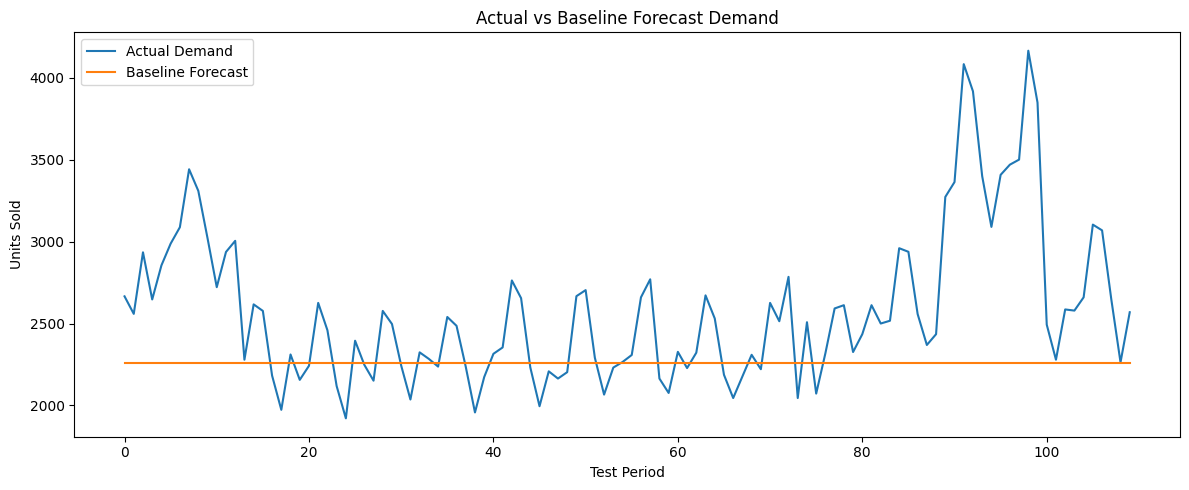

In [40]:
# Visualize actual demand vs baseline forecast

plt.figure(figsize=(12, 5))

plt.plot(
    y_test.values,
    label="Actual Demand"
)

plt.plot(
    baseline_predictions,
    label="Baseline Forecast"
)

plt.title("Actual vs Baseline Forecast Demand")
plt.xlabel("Test Period")
plt.ylabel("Units Sold")
plt.legend()
plt.tight_layout()
plt.show()

In [41]:
# Calculate baseline forecasting performance metrics

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_test, baseline_predictions)

rmse = np.sqrt(
    mean_squared_error(y_test, baseline_predictions)
)

print("Baseline Forecast Performance")
print("-" * 40)
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")

Baseline Forecast Performance
----------------------------------------
MAE  : 383.20
RMSE : 559.54


In [42]:
# Calculate forecast errors

forecast_errors = pd.DataFrame({
    "actual_demand": y_test.values,
    "baseline_forecast": baseline_predictions
})

forecast_errors["error"] = (
    forecast_errors["actual_demand"]
    - forecast_errors["baseline_forecast"]
)

forecast_errors["absolute_error"] = (
    forecast_errors["error"].abs()
)

forecast_errors.head(10)

,actual_demand,baseline_forecast,error,absolute_error
0,2666.0,2262.0,404.0,404.0
1,2559.0,2262.0,297.0,297.0
2,2935.0,2262.0,673.0,673.0
3,2647.0,2262.0,385.0,385.0
4,2855.0,2262.0,593.0,593.0
5,2988.0,2262.0,726.0,726.0
6,3088.0,2262.0,826.0,826.0
7,3442.0,2262.0,1180.0,1180.0
8,3310.0,2262.0,1048.0,1048.0
9,3021.0,2262.0,759.0,759.0


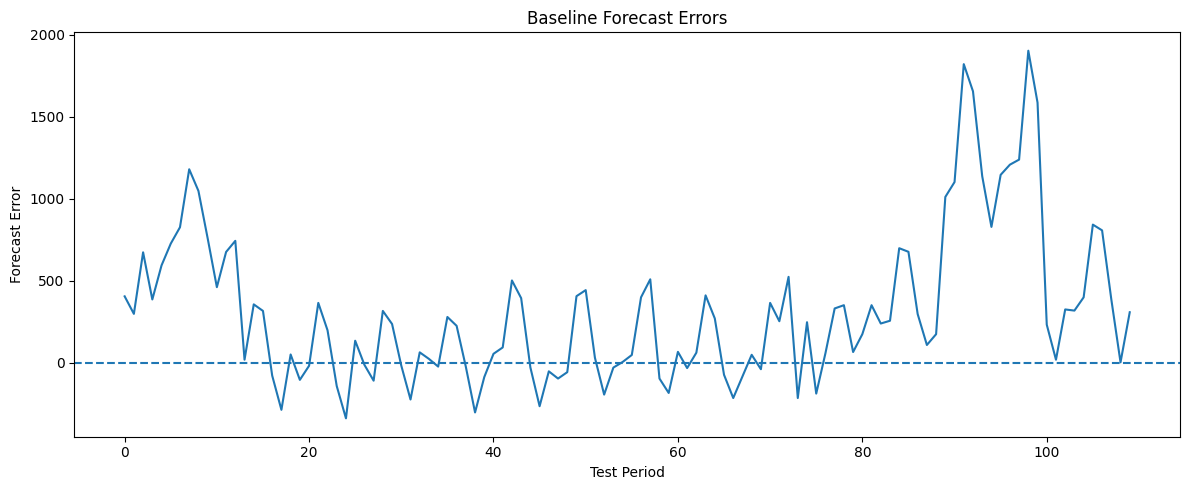

In [43]:
# Visualize forecast errors

plt.figure(figsize=(12, 5))

plt.plot(
    forecast_errors["error"]
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.title("Baseline Forecast Errors")
plt.xlabel("Test Period")
plt.ylabel("Forecast Error")
plt.tight_layout()
plt.show()

In [44]:
# Calculate baseline forecast error metrics

mae = forecast_errors["error"].abs().mean()
rmse = np.sqrt((forecast_errors["error"] ** 2).mean())

print("Baseline Forecast Performance")
print("-" * 40)
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")

Baseline Forecast Performance
----------------------------------------
MAE  : 383.20
RMSE : 559.54


In [45]:
# Calculate baseline forecast error metrics

mae = forecast_errors["error"].abs().mean()
rmse = np.sqrt((forecast_errors["error"] ** 2).mean())

print("Baseline Forecast Performance")
print("-" * 40)
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")

Baseline Forecast Performance
----------------------------------------
Mean Absolute Error (MAE): 383.20
Root Mean Squared Error (RMSE): 559.54


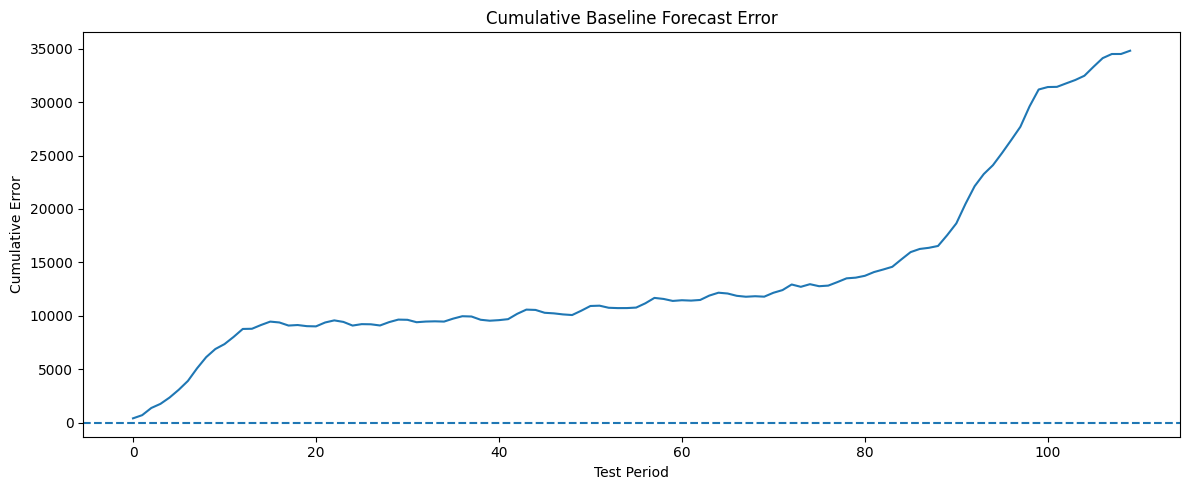

In [46]:
# Calculate cumulative forecast error

forecast_errors["cumulative_error"] = (
    forecast_errors["error"].cumsum()
)

plt.figure(figsize=(12, 5))

plt.plot(
    forecast_errors["cumulative_error"]
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.title("Cumulative Baseline Forecast Error")
plt.xlabel("Test Period")
plt.ylabel("Cumulative Error")
plt.tight_layout()
plt.show()

In [47]:
# Save baseline forecast errors for later model comparison

import os

os.makedirs("../data/processed", exist_ok=True)

forecast_errors.to_csv(
    "../data/processed/baseline_forecast_errors.csv",
    index=False
)

print("Baseline forecast errors saved successfully.")
print(
    "File: ../data/processed/baseline_forecast_errors.csv"
)

Baseline forecast errors saved successfully.
File: ../data/processed/baseline_forecast_errors.csv


## 8. Baseline Forecast Error Analysis

The baseline forecast errors are analyzed to understand the forecasting performance before applying more advanced machine learning models.

The saved error dataset contains the actual demand, predicted demand, and forecast error for the baseline model.

In [53]:
# Check the structure of the forecast error dataset

print("Forecast error columns:")
print(forecast_errors.columns.tolist())

print("\nShape:")
print(forecast_errors.shape)

print("\nFirst 5 rows:")
display(forecast_errors.head())

Forecast error columns:
['actual_demand', 'baseline_forecast', 'error', 'absolute_error', 'cumulative_error']

Shape:
(110, 5)

First 5 rows:


,actual_demand,baseline_forecast,error,absolute_error,cumulative_error
0,2666.0,2262.0,404.0,404.0,404.0
1,2559.0,2262.0,297.0,297.0,701.0
2,2935.0,2262.0,673.0,673.0,1374.0
3,2647.0,2262.0,385.0,385.0,1759.0
4,2855.0,2262.0,593.0,593.0,2352.0


In [4]:
# Load the saved baseline forecast errors

import pandas as pd
import os

file_path = "../data/processed/baseline_forecast_errors.csv"

print("Checking file...")

if os.path.exists(file_path):
    forecast_errors = pd.read_csv(file_path)

    print("Baseline forecast errors loaded successfully.")
    print("Shape:", forecast_errors.shape)
    print("\nColumns:")
    print(forecast_errors.columns.tolist())

    print("\nFirst 5 rows:")
    display(forecast_errors.head())

else:
    print("ERROR: baseline_forecast_errors.csv was not found.")
    print("Expected location:")
    print(file_path)

Checking file...
Baseline forecast errors loaded successfully.
Shape: (110, 5)

Columns:
['actual_demand', 'baseline_forecast', 'error', 'absolute_error', 'cumulative_error']

First 5 rows:


,actual_demand,baseline_forecast,error,absolute_error,cumulative_error
0,2666.0,2262.0,404.0,404.0,404.0
1,2559.0,2262.0,297.0,297.0,701.0
2,2935.0,2262.0,673.0,673.0,1374.0
3,2647.0,2262.0,385.0,385.0,1759.0
4,2855.0,2262.0,593.0,593.0,2352.0


In [5]:
# Inspect the loaded baseline forecast error dataset

print("Baseline Forecast Error Dataset")
print("=" * 45)

print("\nColumns:")
print(forecast_errors.columns.tolist())

print("\nShape:")
print(forecast_errors.shape)

print("\nData Types:")
display(forecast_errors.dtypes)

print("\nFirst 5 Rows:")
display(forecast_errors.head())

Baseline Forecast Error Dataset

Columns:
['actual_demand', 'baseline_forecast', 'error', 'absolute_error', 'cumulative_error']

Shape:
(110, 5)

Data Types:


actual_demand        float64
baseline_forecast    float64
error                float64
absolute_error       float64
cumulative_error     float64
dtype: object


First 5 Rows:


,actual_demand,baseline_forecast,error,absolute_error,cumulative_error
0,2666.0,2262.0,404.0,404.0,404.0
1,2559.0,2262.0,297.0,297.0,701.0
2,2935.0,2262.0,673.0,673.0,1374.0
3,2647.0,2262.0,385.0,385.0,1759.0
4,2855.0,2262.0,593.0,593.0,2352.0


Matplotlib imported successfully.


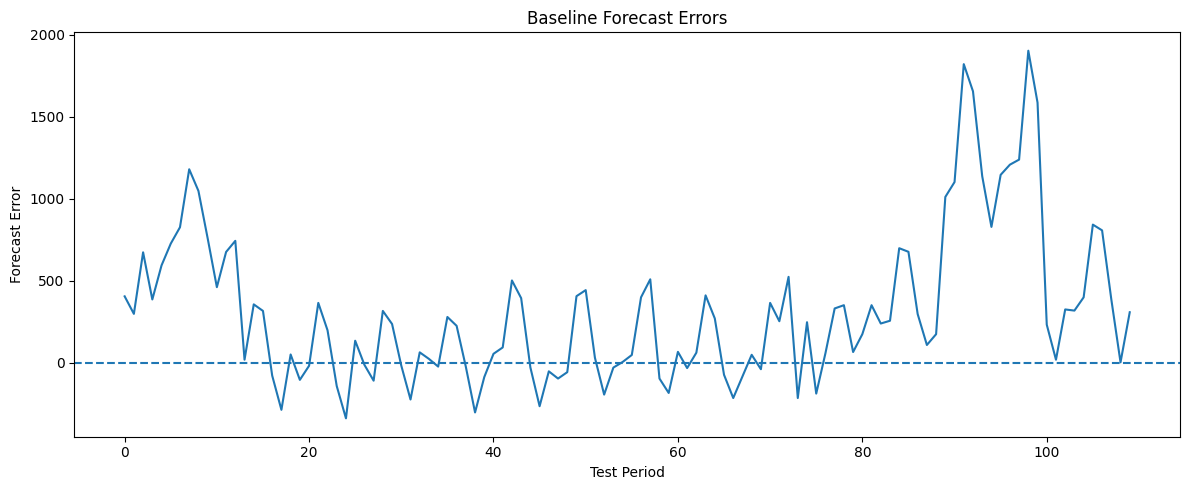

In [7]:
import matplotlib.pyplot as plt

print("Matplotlib imported successfully.")


plt.figure(figsize=(12, 5))

plt.plot(
    forecast_errors["error"]
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.title("Baseline Forecast Errors")
plt.xlabel("Test Period")
plt.ylabel("Forecast Error")

plt.tight_layout()
plt.show()